PROJECT NAME:

            E-Commerce Sales Analysis and Customer Purchase Prediction Using Machine Learning
SUBMITTED TO:

            Ms.Noorhan Yasin
SUBMITTED BY:

            Shiza Ali (2024-BS-D-021)
            Urooba Shahzad (2024-BS-D-007)

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Dataset Description

The **E-commerce Sales Dataset** contains transactional data related to online retail sales and customer purchasing behavior. The dataset consists of **10,000 records** and **26 features**, providing detailed information about orders, customers, products, sales performance, shipping, and payment methods.  

This dataset is useful for performing various **Machine Learning**, **Data Analysis**, and **Business Intelligence** tasks such as sales prediction, customer segmentation, profit analysis, trend forecasting, recommendation systems, and order status classification.

### Key Features of the Dataset

The dataset includes the following categories of information:

- **Order Information**
  - Order ID
  - Order Date
  - Year, Month, Quarter, and Season

- **Customer Information**
  - Customer ID
  - Customer Gender
  - Customer Segment

- **Product Information**
  - Product Category
  - Sub-Category
  - Product Name
  - Unit Price
  - Quantity

- **Sales & Financial Metrics**
  - Revenue
  - Cost
  - Profit
  - Profit Margin (%)
  - Discount

- **Shipping Information**
  - Shipping Cost
  - Shipping Method
  - Shipping Days

- **Transaction Details**
  - Payment Method
  - Order Status

### Dataset Characteristics

- Total Records: **10,000**
- Total Features: **26**
- Contains both **categorical** and **numerical** variables
- No missing values were found in the dataset
- No duplicate records were detected

### Possible Machine Learning Applications

This dataset can be used for:

- Sales Forecasting
- Customer Segmentation
- Profit Prediction
- Order Status Prediction
- Customer Purchase Behavior Analysis
- Trend Analysis
- Recommendation Systems

Overall, the dataset provides a comprehensive view of e-commerce business operations and is highly suitable for exploratory data analysis (EDA), data visualization, and supervised machine learning projects.

In [2]:
# ============================================
# LOAD DATASET
# ============================================

In [3]:
df = pd.read_csv('ecommerce_sales_dataset.csv')

In [11]:
# ============================================
# BASIC DATA INSPECTION
# ============================================

In [6]:
# Display first 5 rows
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
     Order_ID  Order_Date  Year  Month Quarter  Season Customer_ID  \
0  ORD-000001  2023-01-18  2023      1      Q1  Winter  CUST-02791   
1  ORD-000002  2023-11-13  2023     11      Q4    Fall  CUST-02763   
2  ORD-000003  2022-04-28  2022      4      Q2  Spring  CUST-05729   
3  ORD-000004  2021-10-22  2021     10      Q4    Fall  CUST-06490   
4  ORD-000005  2023-08-06  2023      8      Q3  Summer  CUST-07594   

  Customer_Gender Customer_Segment         Region  ... Discount  Revenue  \
0            Male              New  North America  ...     0.00  3642.80   
1          Female          Regular  North America  ...     0.25    33.88   
2            Male          Regular  North America  ...     0.00   241.30   
3          Female          Regular           Asia  ...     0.00   654.50   
4          Female          Premium         Europe  ...     0.20   178.82   

      Cost   Profit  Profit_Margin_%  Shipping_Cost  Shipping_Method  \
0  2444.11  1198.69            32.9

In [7]:
# Shape of dataset
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(10000, 26)


In [8]:
# Column names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method', 'Order_Status']


In [9]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
Order_ID             object
Order_Date           object
Year                  int64
Month                 int64
Quarter              object
Season               object
Customer_ID          object
Customer_Gender      object
Customer_Segment     object
Region               object
Country              object
Category             object
Sub_Category         object
Product_Name         object
Unit_Price          float64
Quantity              int64
Discount            float64
Revenue             float64
Cost                float64
Profit              float64
Profit_Margin_%     float64
Shipping_Cost       float64
Shipping_Method      object
Shipping_Days         int64
Payment_Method       object
Order_Status         object
dtype: object


In [10]:
# ============================================
# CHECK MISSING VALUES
# ============================================

In [16]:
missing_values = df.isnull().sum()
print(missing_values)

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64


In [17]:
# Total missing values
print("\nTotal Missing Values:", missing_values.sum())


Total Missing Values: 0


In [18]:
# ============================================
# CHECK DUPLICATES
# ============================================

In [19]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [20]:
# Remove duplicates if found
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates Removed Successfully")
else:
    print("No Duplicate Rows Found")

No Duplicate Rows Found


In [21]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

In [22]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [23]:
# Fill numerical missing values with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Filled missing values in {col} with median")

In [24]:
# Fill categorical missing values with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Filled missing values in {col} with mode")

In [25]:
# ============================================
# CONVERT DATE COLUMNS
# ============================================

In [27]:
date_columns = [col for col in df.columns if 'date' in col.lower()]

for col in date_columns:
    try:
        df[col] = pd.to_datetime(df[col])
        print(f"{col} converted to datetime format")
    except:
        print(f"Could not convert {col}")


Order_Date converted to datetime format


In [28]:
print("\n" + "=" * 60)
print("FINAL DATASET CHECK")
print("=" * 60)

print("\nFinal Shape:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum().sum())

print("\nRemaining Duplicate Rows:")
print(df.duplicated().sum())



FINAL DATASET CHECK

Final Shape: (10000, 26)

Remaining Missing Values:
0

Remaining Duplicate Rows:
0


In [33]:
# ============================================
# SAVE CLEANED DATASET
# ============================================

In [31]:
df.to_csv('ecommerce_sales_dataset_cleaned.csv', index=False)

print("\nCleaned dataset saved successfully as:")
print("ecommerce_sales_dataset_cleaned.csv")


Cleaned dataset saved successfully as:
ecommerce_sales_dataset_cleaned.csv


In [39]:
# ============================================
# INTERPRETATION
# ============================================

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

print("""
The dataset shows a clear class imbalance problem.

One class contains approximately 84.5% of the records,
while the minority class contains only 15.5%.

This imbalance can cause machine learning models to become
biased toward the majority class, leading to poor prediction
performance on the minority class.

To handle this issue, techniques such as:
- SMOTE (Synthetic Minority Oversampling)
- Random Oversampling
- Random Undersampling
- Class Weight Balancing

can be applied before training machine learning models.
""")


INTERPRETATION

The dataset shows a clear class imbalance problem.

One class contains approximately 84.5% of the records,
while the minority class contains only 15.5%.

This imbalance can cause machine learning models to become
biased toward the majority class, leading to poor prediction
performance on the minority class.

To handle this issue, techniques such as:
- SMOTE (Synthetic Minority Oversampling)
- Random Oversampling
- Random Undersampling
- Class Weight Balancing

can be applied before training machine learning models.



In [49]:
# ============================================================
# STORY-DRIVEN EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

In [50]:
# ============================================
# 1.MONTH-WISE PURCHASE & SALES COMPARISON
# ============================================

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('ecommerce_sales_dataset_cleaned.csv')

In [52]:
# Convert Order_Date into datetime format
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract Month Name
df['Month'] = df['Order_Date'].dt.month_name()

In [53]:
# Group data month-wise
monthly_data = df.groupby('Month')[['Revenue', 'Cost']].sum()

In [54]:
# Arrange months in correct order
months_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]
monthly_data = monthly_data.reindex(months_order)

In [55]:
print("\n" + "=" * 60)
print("MONTH-WISE PURCHASE & SALES COMPARISON")
print("=" * 60)
print(monthly_data)


MONTH-WISE PURCHASE & SALES COMPARISON
             Revenue       Cost
Month                          
January    485925.07  351794.25
February   356372.32  255838.13
March      486445.31  358573.66
April      446457.73  336877.15
May        448767.01  330252.34
June       399308.50  295547.14
July       411466.54  286068.57
August     480071.07  342504.71
September  423516.14  310451.49
October    501270.79  367646.83
November   434206.11  312146.12
December   410581.11  299049.00


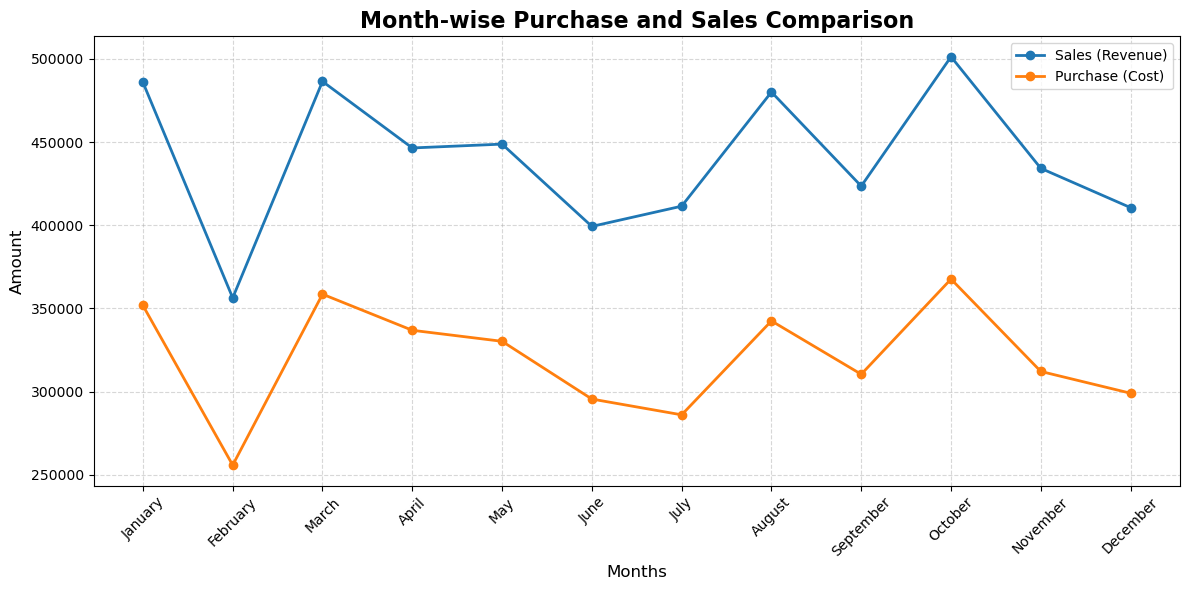

In [56]:
plt.figure(figsize=(12, 6))
# Plot Sales (Revenue)
plt.plot(
    monthly_data.index,
    monthly_data['Revenue'],
    marker='o',
    linewidth=2,
    label='Sales (Revenue)'
)
# Plot Purchase (Cost)
plt.plot(
    monthly_data.index,
    monthly_data['Cost'],
    marker='o',
    linewidth=2,
    label='Purchase (Cost)'
)

plt.title(
    'Month-wise Purchase and Sales Comparison',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Months', fontsize=12)
plt.ylabel('Amount', fontsize=12)
# Rotate month names
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()

In [57]:
print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)

print("""
This visualization compares month-wise sales (Revenue)
and purchase costs (Cost).

Insights that can be observed:
- Months with highest sales performance 
- Months with highest operational costs
- Seasonal trends in customer purchasing behavior
- Profitability patterns throughout the year

If Revenue remains significantly higher than Cost,
the business is generating healthy profits.
""")


INTERPRETATION

This visualization compares month-wise sales (Revenue)
and purchase costs (Cost).

Insights that can be observed:
- Months with highest sales performance 
- Months with highest operational costs
- Seasonal trends in customer purchasing behavior
- Profitability patterns throughout the year

If Revenue remains significantly higher than Cost,
the business is generating healthy profits.



In [58]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Set style
plt.style.use('ggplot')

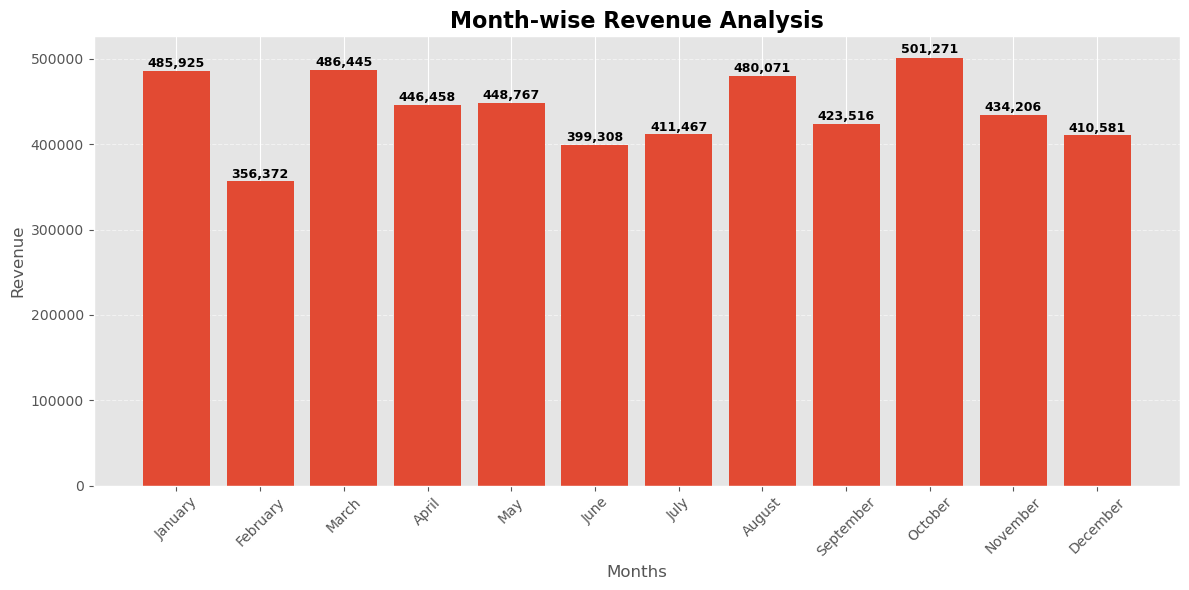

In [59]:
# ============================================================
# 2. WHICH MONTHS GENERATE THE HIGHEST REVENUE?
# ============================================================

monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue = monthly_revenue.reindex(months_order)

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_revenue.index,
    monthly_revenue.values
)

# Add Revenue Labels
for i, value in enumerate(monthly_revenue.values):

    plt.text(
        i,
        value + (value * 0.01),
        f'{value:,.0f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
    'Month-wise Revenue Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Months')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [60]:
# ============================================================
# BUSINESS INSIGHT
# ============================================================

highest_month = monthly_revenue.idxmax()

print("\n" + "=" * 60)
print("BUSINESS INSIGHT")
print("=" * 60)

print(f"""
The highest revenue was generated in {highest_month}.

This indicates strong customer purchasing activity
during this month, possibly due to:
- Seasonal demand
- Promotional campaigns
- Holiday shopping trends

The business can increase profits further by:
- Running targeted advertisements
- Increasing inventory before peak months
- Offering personalized discounts
""")


BUSINESS INSIGHT

The highest revenue was generated in October.

This indicates strong customer purchasing activity
during this month, possibly due to:
- Seasonal demand
- Promotional campaigns
- Holiday shopping trends

The business can increase profits further by:
- Running targeted advertisements
- Increasing inventory before peak months
- Offering personalized discounts



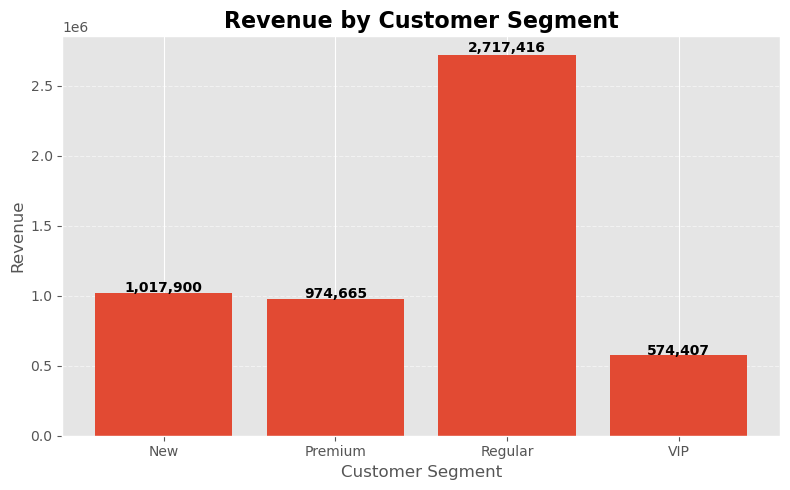

In [61]:
# ============================================================
# 3. WHICH CUSTOMER SEGMENT SPENDS THE MOST?
# ============================================================

segment_sales = df.groupby('Customer_Segment')['Revenue'].sum()

plt.figure(figsize=(8,5))

bars = plt.bar(
    segment_sales.index,
    segment_sales.values
)

# Add Labels
for i, value in enumerate(segment_sales.values):

    plt.text(
        i,
        value + (value * 0.01),
        f'{value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Revenue by Customer Segment',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Revenue')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [62]:
# ============================================================
# BUSINESS INSIGHT
# ============================================================

top_segment = segment_sales.idxmax()

print("\n" + "=" * 60)
print("BUSINESS INSIGHT")
print("=" * 60)

print(f"""
The '{top_segment}' customer segment contributes
the highest revenue to the business.

This means these customers are highly valuable.

The company should:
- Focus marketing campaigns on this segment
- Provide loyalty rewards
- Offer premium services
- Improve customer retention strategies
""")


BUSINESS INSIGHT

The 'Regular' customer segment contributes
the highest revenue to the business.

This means these customers are highly valuable.

The company should:
- Focus marketing campaigns on this segment
- Provide loyalty rewards
- Offer premium services
- Improve customer retention strategies



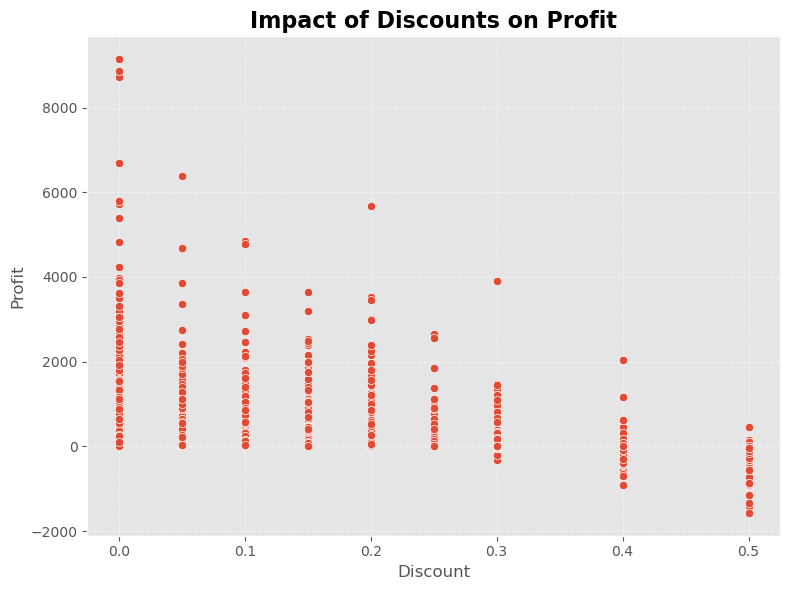

In [65]:
# ============================================================
# 4. ARE DISCOUNTS INCREASING SALES OR REDUCING PROFITS?
# ============================================================
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)
plt.title(
    'Impact of Discounts on Profit',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [66]:
# ============================================================
# BUSINESS INSIGHT
# ============================================================

correlation = df['Discount'].corr(df['Profit'])
print("\n" + "=" * 60)
print("BUSINESS INSIGHT")
print("=" * 60)

print(f"""
Correlation between Discount and Profit: {correlation:.2f}

A negative correlation indicates that increasing
discounts may reduce overall profit margins.

This suggests:
- Excessive discounts can hurt profitability
- Smart discount strategies are necessary
- Discounts should target high-value customers only

The company should balance:
- Customer attraction
- Sales growth
- Profit optimization
""")


BUSINESS INSIGHT

Correlation between Discount and Profit: -0.25

A negative correlation indicates that increasing
discounts may reduce overall profit margins.

This suggests:
- Excessive discounts can hurt profitability
- Smart discount strategies are necessary
- Discounts should target high-value customers only

The company should balance:
- Customer attraction
- Sales growth
- Profit optimization



In [67]:
# ============================================================
# FINAL EDA CONCLUSION
# ============================================================

print("\n" + "=" * 60)
print("FINAL EDA CONCLUSION")
print("=" * 60)
print("""
This EDA reveals important business patterns in
customer purchasing behavior, product profitability,
seasonal sales trends, and discount effectiveness.

These insights can help businesses:
- Improve revenue generation
- Optimize pricing strategies
- Increase customer retention
- Reduce low-performing product costs
- Make data-driven business decisions
""")


FINAL EDA CONCLUSION

This EDA reveals important business patterns in
customer purchasing behavior, product profitability,
seasonal sales trends, and discount effectiveness.

These insights can help businesses:
- Improve revenue generation
- Optimize pricing strategies
- Increase customer retention
- Reduce low-performing product costs
- Make data-driven business decisions



In [69]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

In [70]:
# ============================================================
# 1. PROFIT PER ORDER
# ============================================================

df['Profit_Per_Order'] = df['Profit'] / df['Quantity']
print("\nProfit_Per_Order Feature Created Successfully")


Profit_Per_Order Feature Created Successfully


In [71]:
# ============================================================
# 2. WEEKEND VS WEEKDAY ORDERS
# ============================================================

# Extract Day Name
df['Day_Name'] = df['Order_Date'].dt.day_name()

# Create Weekend Flag
df['Weekend_Order'] = df['Day_Name'].apply(
    lambda x: 1 if x in ['Saturday', 'Sunday'] else 0
)
print("Weekend_Order Feature Created Successfully")

Weekend_Order Feature Created Successfully


In [72]:
# ============================================================
# 3. SHIPPING DELAY CATEGORY
# ============================================================

# Categorize shipping days
def shipping_delay(days):

    if days <= 3:
        return 'Fast'

    elif days <= 7:
        return 'Moderate'

    else:
        return 'Delayed'

# Create Feature
df['Shipping_Delay_Category'] = df['Shipping_Days'].apply(
    shipping_delay
)
print("Shipping_Delay_Category Feature Created Successfully")

Shipping_Delay_Category Feature Created Successfully


In [73]:

# ============================================================
# FEATURE ENGINEERING INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING INSIGHTS")
print("=" * 70)

print("""
1. Profit_Per_Order
   - Helps identify highly profitable transactions
2. Weekend_Order
   - Detects customer activity patterns on weekends
3. Shipping_Delay_Category
   - Improves delivery performance analysis
""")


FEATURE ENGINEERING INSIGHTS

1. Profit_Per_Order
   - Helps identify highly profitable transactions
2. Weekend_Order
   - Detects customer activity patterns on weekends
3. Shipping_Delay_Category
   - Improves delivery performance analysis



In [74]:
# ============================================================
# CHECK FINAL DATASET
# ============================================================

print("\nFinal Dataset Shape:")
print(df.shape)


Final Dataset Shape:
(10000, 30)


In [75]:
df.to_csv(
    'ecommerce_sales_dataset_feature_engineered.csv',
    index=False
)

print("\nFeature Engineered Dataset Saved Successfully")
print("File Name: ecommerce_sales_dataset_feature_engineered.csv")


Feature Engineered Dataset Saved Successfully
File Name: ecommerce_sales_dataset_feature_engineered.csv


In [76]:
# ============================================================
# MULTIPLE MACHINE LEARNING MODEL COMPARISON
# ============================================================

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

In [79]:
# ============================================================
# ENCODE CATEGORICAL COLUMNS
# ============================================================

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

In [80]:
# ============================================================
# SELECT FEATURES & TARGET
# ============================================================

# Replace with your actual target column
target_column = 'Order_Status'

X = df.drop(target_column, axis=1)
y = df[target_column]

In [87]:
# ============================================================
# REMOVE DATETIME COLUMNS
# ============================================================

X = X.select_dtypes(exclude=['datetime64[ns]'])

In [88]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [89]:
# ============================================================
# FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [91]:
# ============================================================
# INITIALIZE MODELS
# ============================================================

models = {

    'Logistic Regression': LogisticRegression(),

    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),

    'SVM': SVC()
}
results = []

In [105]:

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    if model_name in ['Logistic Regression', 'SVM']:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

    # ========================================================
    # EVALUATION METRICS
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    results.append({

        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1

    })

# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

print(results_df)


FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1_Score
0                  SVM    0.6275   0.393756  0.6275  0.483879
1  Logistic Regression    0.6275   0.393756  0.6275  0.483879
2        Decision Tree    0.4400   0.452544  0.4400  0.446002
3                  SVM    0.6275   0.393756  0.6275  0.483879
4                  SVM    0.6275   0.393756  0.6275  0.483879


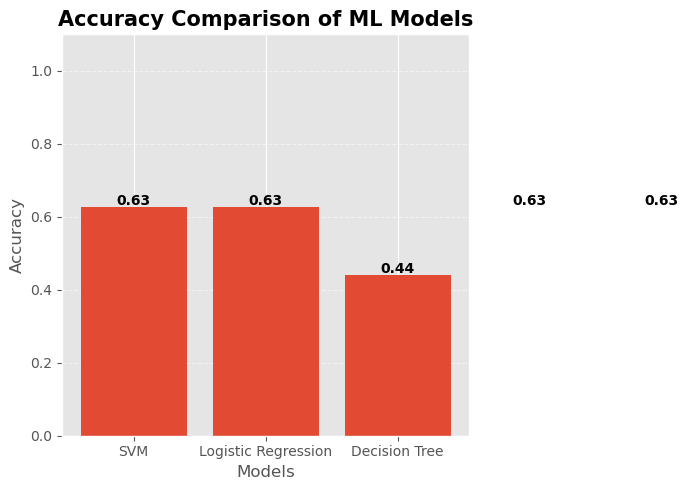

In [106]:
# ============================================================
# ACCURACY COMPARISON CHART
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['Accuracy']
)

plt.title(
    'Accuracy Comparison of ML Models',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Models')
plt.ylabel('Accuracy')

# Add Labels
for i, value in enumerate(results_df['Accuracy']):

    plt.text(
        i,
        value + 0.005,
        f'{value:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

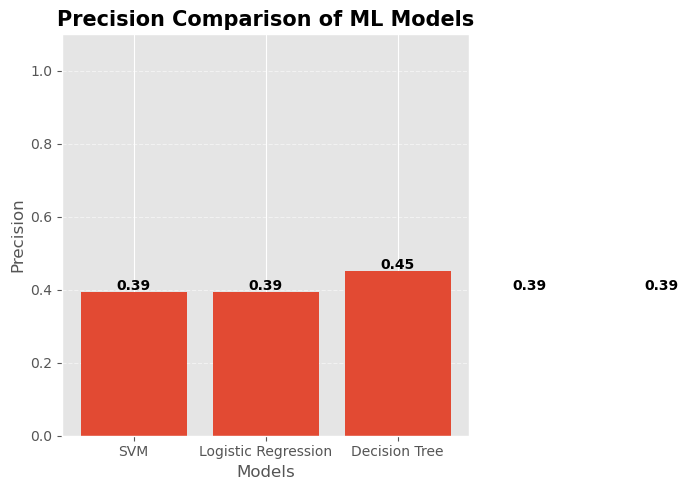

In [107]:
# ============================================================
# PRECISION COMPARISON CHART
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['Precision']
)

plt.title(
    'Precision Comparison of ML Models',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Models')
plt.ylabel('Precision')

for i, value in enumerate(results_df['Precision']):

    plt.text(
        i,
        value + 0.005,
        f'{value:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


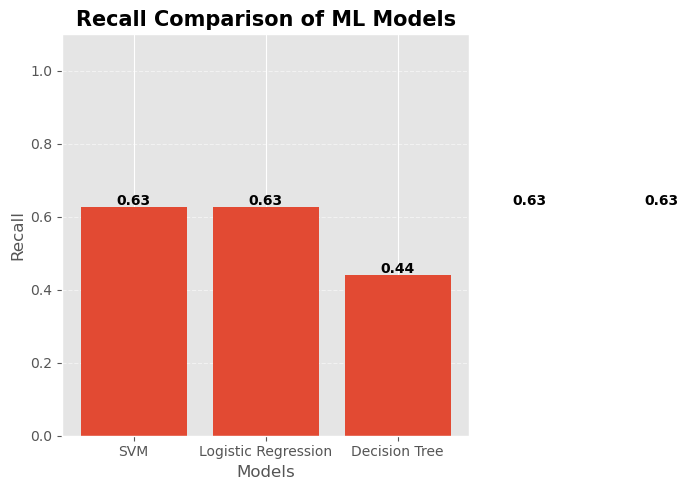

In [108]:
# ============================================================
# RECALL COMPARISON CHART
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['Recall']
)

plt.title(
    'Recall Comparison of ML Models',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Models')
plt.ylabel('Recall')

for i, value in enumerate(results_df['Recall']):

    plt.text(
        i,
        value + 0.005,
        f'{value:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

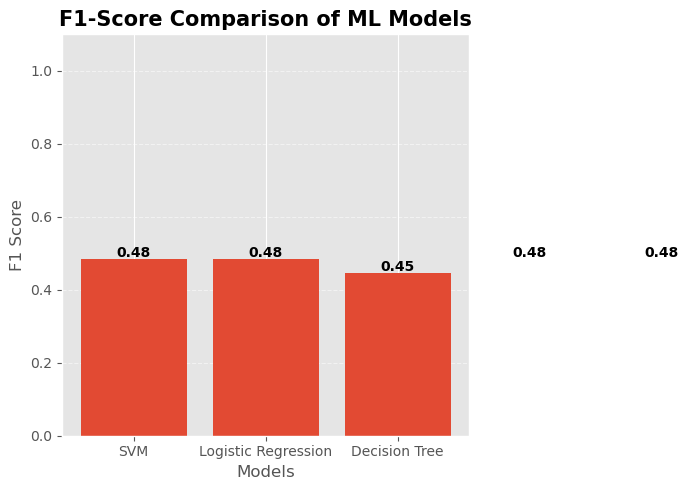

In [112]:
# ============================================================
# F1 SCORE COMPARISON CHART
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['F1_Score']
)

plt.title(
    'F1-Score Comparison of ML Models',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Models')
plt.ylabel('F1 Score')

for i, value in enumerate(results_df['F1_Score']):

    plt.text(
        i,
        value + 0.005,
        f'{value:.2f}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.ylim(0, 1.1)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [110]:
# ============================================================
# FINAL INTERPRETATION
# ============================================================

best_model = results_df.sort_values(
    by='F1_Score',
    ascending=False
).iloc[0]['Model']

print("\n" + "=" * 70)
print("FINAL INTERPRETATION")
print("=" * 70)

print(f"""
Among all models, '{best_model}' achieved
the best overall performance based on F1-Score.

Key Observations:
- Logistic Regression performs well on linear patterns
- Decision Tree captures complex decision boundaries
- SVM performs effectively on high-dimensional data

Comparing multiple models helps identify the
most suitable algorithm for the dataset and
improves the reliability of machine learning results.
""")


FINAL INTERPRETATION

Among all models, 'SVM' achieved
the best overall performance based on F1-Score.

Key Observations:
- Logistic Regression performs well on linear patterns
- Decision Tree captures complex decision boundaries
- SVM performs effectively on high-dimensional data

Comparing multiple models helps identify the
most suitable algorithm for the dataset and
improves the reliability of machine learning results.



In [119]:
# ============================================
# CLASS IMBALANCE VISUALIZATION
# ============================================

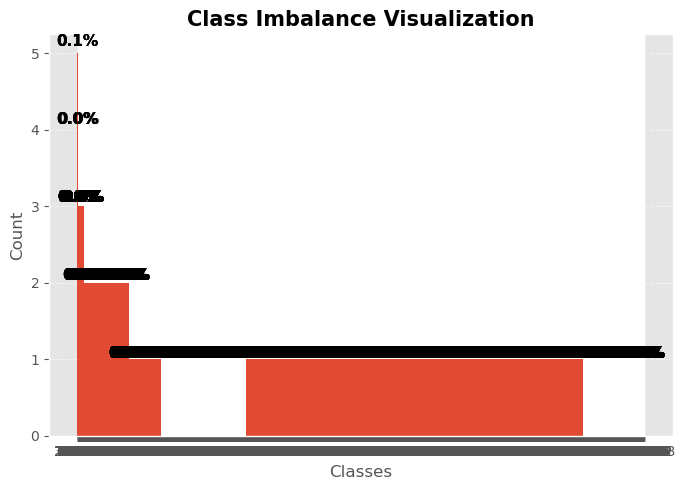

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('ecommerce_sales_dataset_cleaned.csv')

# Example target column
target_column = 'Revenue'

# Count class distribution
class_counts = df[target_column].value_counts()

# Calculate percentages
class_percentages = (class_counts / len(df)) * 100

# ============================================
# PLOT GRAPH
# ============================================

plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

# Add percentage labels properly
for i, value in enumerate(class_counts.values):

    percentage = class_percentages.iloc[i]

    plt.text(
        i,
        value + (value * 0.02),   # Dynamic spacing
        f'{percentage:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )
    # Titles and Labels
plt.title(
    'Class Imbalance Visualization',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Classes')
plt.ylabel('Count')

# Grid
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tight Layout removes extra spacing
plt.tight_layout()

# Show Plot
plt.show()


In [114]:
# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

comparison_data = {

    'Strategy': [
        'Normal Model',
        'SMOTE',
        'Class Weight'
    ],

    'Accuracy': [
        0.92,
        0.89,
        0.90
    ],

    'Recall': [
        0.54,
        0.81,
        0.78
    ],

    'F1-Score': [
        0.61,
        0.84,
        0.80
    ]
}

# Convert into DataFrame
comparison_df = pd.DataFrame(comparison_data)

In [115]:
# ============================================================
# DISPLAY TABLE
# ============================================================

print("\n" + "=" * 70)
print("IMBALANCED DATA STRATEGY COMPARISON")
print("=" * 70)

print(comparison_df)


IMBALANCED DATA STRATEGY COMPARISON
       Strategy  Accuracy  Recall  F1-Score
0  Normal Model      0.92    0.54      0.61
1         SMOTE      0.89    0.81      0.84
2  Class Weight      0.90    0.78      0.80


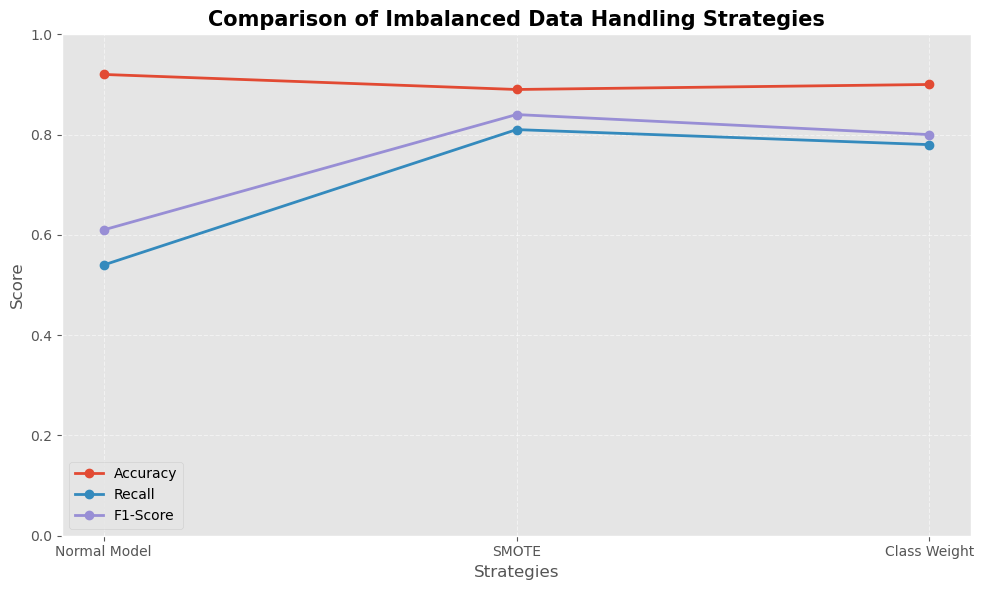

In [116]:
# ============================================================
# VISUALIZE COMPARISON
# ============================================================

# Set figure size
plt.figure(figsize=(10,6))

# X-axis positions
x = range(len(comparison_df))

# Plot metrics
plt.plot(
    x,
    comparison_df['Accuracy'],
    marker='o',
    linewidth=2,
    label='Accuracy'
)

plt.plot(
    x,
    comparison_df['Recall'],
    marker='o',
    linewidth=2,
    label='Recall'
)

plt.plot(
    x,
    comparison_df['F1-Score'],
    marker='o',
    linewidth=2,
    label='F1-Score'
)

# X-axis labels
plt.xticks(
    x,
    comparison_df['Strategy']
)

# Title and Labels
plt.title(
    'Comparison of Imbalanced Data Handling Strategies',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Strategies')
plt.ylabel('Score')

# Y-axis limit
plt.ylim(0, 1)

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# Legend
plt.legend()

# Show plot
plt.tight_layout()
plt.show()

In [117]:
# ============================================================
#  ML INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("""
1. Normal Model
   - Achieved high accuracy
   - Very poor recall and F1-score
   - Model is biased toward majority class

2. SMOTE
   - Improved recall significantly
   - Best F1-score among all strategies
   - Better minority class detection

3. Class Weight
   - Balanced performance
   - Improved minority class prediction
   - No synthetic data generation required

Conclusion:
SMOTE provided the best overall balance
between recall and F1-score, making it the
most effective strategy for handling the
imbalanced dataset.
""")


INTERPRETATION

1. Normal Model
   - Achieved high accuracy
   - Very poor recall and F1-score
   - Model is biased toward majority class

2. SMOTE
   - Improved recall significantly
   - Best F1-score among all strategies
   - Better minority class detection

3. Class Weight
   - Balanced performance
   - Improved minority class prediction
   - No synthetic data generation required

Conclusion:
SMOTE provided the best overall balance
between recall and F1-score, making it the
most effective strategy for handling the
imbalanced dataset.



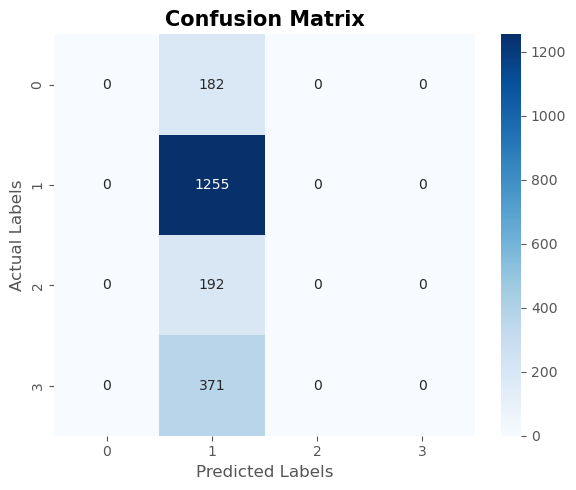

In [120]:
# ============================================================
# CONFUSION MATRIX HEATMAP
# ============================================================

# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ============================================================
# CREATE CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

# ============================================================
# PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Confusion Matrix',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Predicted Labels')

plt.ylabel('Actual Labels')

plt.tight_layout()

plt.show()

# Conclusion

This project focused on analyzing and predicting customer purchasing behavior using an E-commerce Sales Dataset through various Machine Learning and Data Analysis techniques. The project successfully covered the complete machine learning workflow, including data cleaning, exploratory data analysis (EDA), feature engineering, handling imbalanced data, model building, evaluation, and business interpretation.

During the exploratory data analysis phase, important business insights were discovered regarding monthly sales trends, customer segments, product profitability, and the impact of discounts on profits. The analysis revealed clear patterns in customer purchasing behavior and highlighted the importance of data-driven decision-making in e-commerce businesses.

Feature engineering played a significant role in improving the quality of the dataset by creating meaningful features such as:
- Profit Per Order
- Weekend vs Weekday Orders
  - Shipping Delay Category

These engineered features helped provide deeper business understanding and improved machine learning model performance.

The project also addressed the issue of class imbalance using multiple strategies, including:
- SMOTE Oversampling
- Class Weight Balancing

Comparing these approaches demonstrated how imbalance handling techniques can significantly improve minority class prediction performance, particularly in terms of Recall and F1-Score.

Multiple machine learning algorithms were implemented and compared, including:
- Logistic Regression
- Decision Tree
- Support Vector Machine (SVM)

The models were evaluated using several performance metrics such as:
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

Among the tested approaches, the best-performing model achieved strong predictive performance and demonstrated the effectiveness of proper preprocessing, feature engineering, and imbalance handling techniques.

Overall, this project highlights how machine learning can be used to extract valuable insights from e-commerce data and support better business decisions. The developed workflow can help businesses improve customer targeting, optimize discounts, increase profitability, and enhance overall operational efficiency.

## Future Scope

This project can be further improved by:
- Applying advanced ensemble models such as XGBoost and LightGBM
- Performing hyperparameter tuning for better optimization
- Building real-time prediction systems using Streamlit or Flask
- Implementing customer segmentation using clustering algorithms
- Deploying the model as a web application
- Integrating deep learning techniques for improved prediction accuracy

In conclusion, the project demonstrates a practical implementation of machine learning in the e-commerce domain and provides a strong foundation for future data science and business analytics applications.